## Introduction


### Dataset
The dataset used for this analysis is the "Fake News Classification" dataset from Kaggle. It contains news articles labeled as "fake" or "real". The dataset includes the following columns:
- `id`: Unique identifier for each news article
- `title`: The title of the news article
- `text`: The full text of the news article
- `label`: The label indicating whether the news is "fake" (0) or "real" (1)

### Objective
The objective of this analysis is to build a machine learning model that can classify news articles as fake or real based on their content.
We will perform the following steps:
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building
5. Model Evaluation
6. Statistical Test
7. Best Model Retraining and Evaluation
8. Conclusion and Future Works

In [1]:
import nltk
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import sparse
import joblib

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd

from spellchecker import SpellChecker
from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
import lightgbm as lgb

import shap
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

from statsmodels.stats.contingency_tables import mcnemar

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from sklearn.feature_selection import SelectKBest, chi2


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Analysis and Preprocessing

In [2]:
df = pd.read_csv("WELFake_Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [4]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


### Global Missing Values
The initial script phase calculates the absolute count of missing entries for every column. It computes the corresponding percentage relative to the total dataset size. The system outputs these statistics inside a unified summary table.

### Stratified Missing Values by Target Class
The second script phase analyzes the distribution of missing data within each target class. The algorithm groups the data observations by the target variable label. It isolates the title and text columns for each sub-group. The loop counts the missing rows and calculates their relative proportion within that specific class subset. This breakdown identifies potential data imbalances or structural anomalies in the data collection process.

In [5]:
total_missing = df.isnull().sum()
percent_missing = (df.isnull().sum() / len(df)) * 100

general_missing_df = pd.DataFrame(
    {"Missing Count": total_missing, "Percentage (%)": percent_missing}
)
print(general_missing_df)

for class_label, group in df.groupby("label"):
    total_class_elements = len(group)

    title_missing_count = group["title"].isnull().sum()
    text_missing_count = group["text"].isnull().sum()

    title_missing_pct = (title_missing_count / total_class_elements) * 100
    text_missing_pct = (text_missing_count / total_class_elements) * 100

    print(f"Classe: {class_label}")
    print(f"  title: {title_missing_count} ({title_missing_pct:.2f}%)")
    print(f"  text: {text_missing_count} ({text_missing_pct:.2f}%)")

            Missing Count  Percentage (%)
Unnamed: 0              0        0.000000
title                 558        0.773560
text                   39        0.054066
label                   0        0.000000
Classe: 0
  title: 0 (0.00%)
  text: 0 (0.00%)
Classe: 1
  title: 558 (1.50%)
  text: 39 (0.11%)


Class distribution

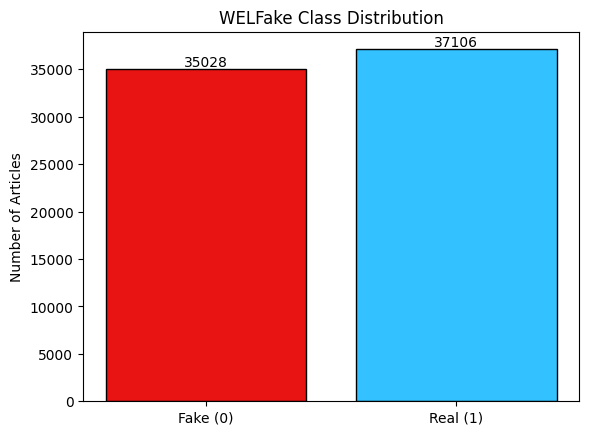

In [3]:
counts = df['label'].value_counts().sort_index()

labels = ['Fake (0)', 'Real (1)']
values = [counts.get(0, 0), counts.get(1, 0)]

colors = ["#E81313", '#33C1FF']

# Plot
plt.figure()
bars = plt.bar(labels, values, color=colors, edgecolor='black')

# title and labels
plt.title('WELFake Class Distribution')
plt.ylabel('Number of Articles')

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.show()

In [7]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

Text length statistics

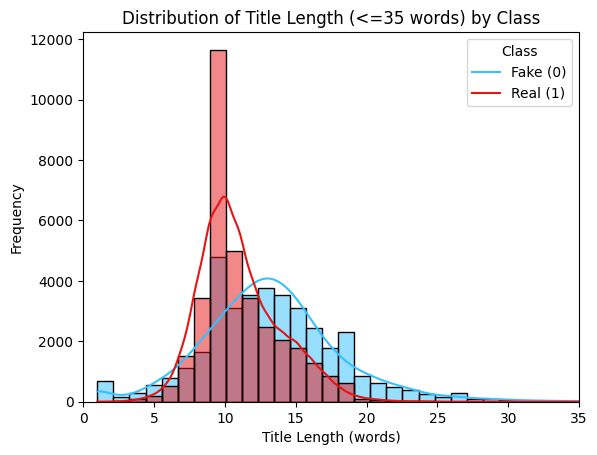

In [7]:
# title length
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(data=df[df['title_length']<=35], x='title_length', hue='label', bins=30, kde=True, kde_kws={'bw_adjust': 1.5}, palette=colors)
plt.title('Distribution of Title Length (<=35 words) by Class')
plt.xlabel('Title Length (words)')
plt.ylabel('Frequency')
plt.xlim(0, 35)
plt.legend(title='Class', labels=['Fake (0)', 'Real (1)'])
plt.show()

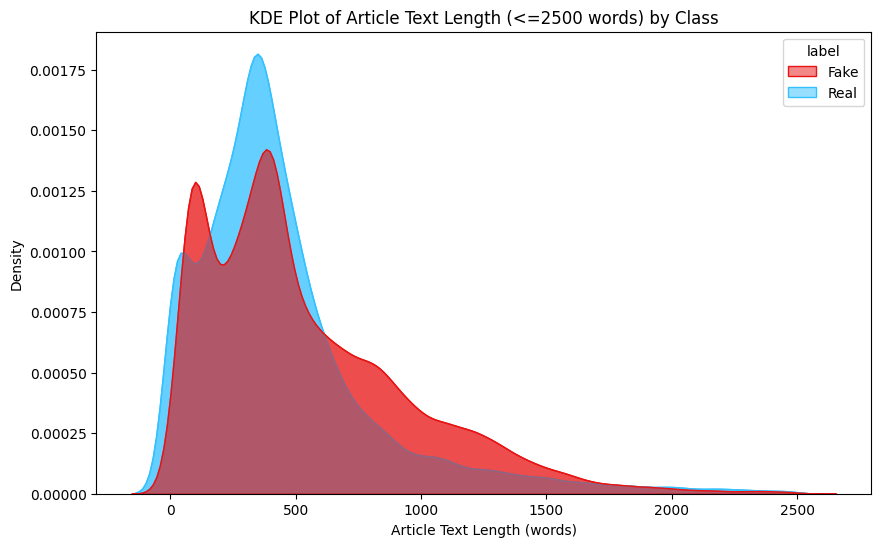

In [19]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
colors = ["#E81313", '#33C1FF']
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['text_length']<=2500], x='text_length', hue='label', fill=True, common_norm=False, palette=colors, alpha=0.5)
plt.title('KDE Plot of Article Text Length (<=2500 words) by Class')
plt.xlabel('Article Text Length (words)')
plt.ylabel('Density')
ax = sns.kdeplot(
    data=df[df['text_length'] <= 2500],
    x='text_length',
    hue='label',
    fill=True,
    common_norm=False,
    palette=colors,
    alpha=0.5
)

legend = ax.get_legend()
legend.texts[0].set_text('Fake')
legend.texts[1].set_text('Real')
plt.show()


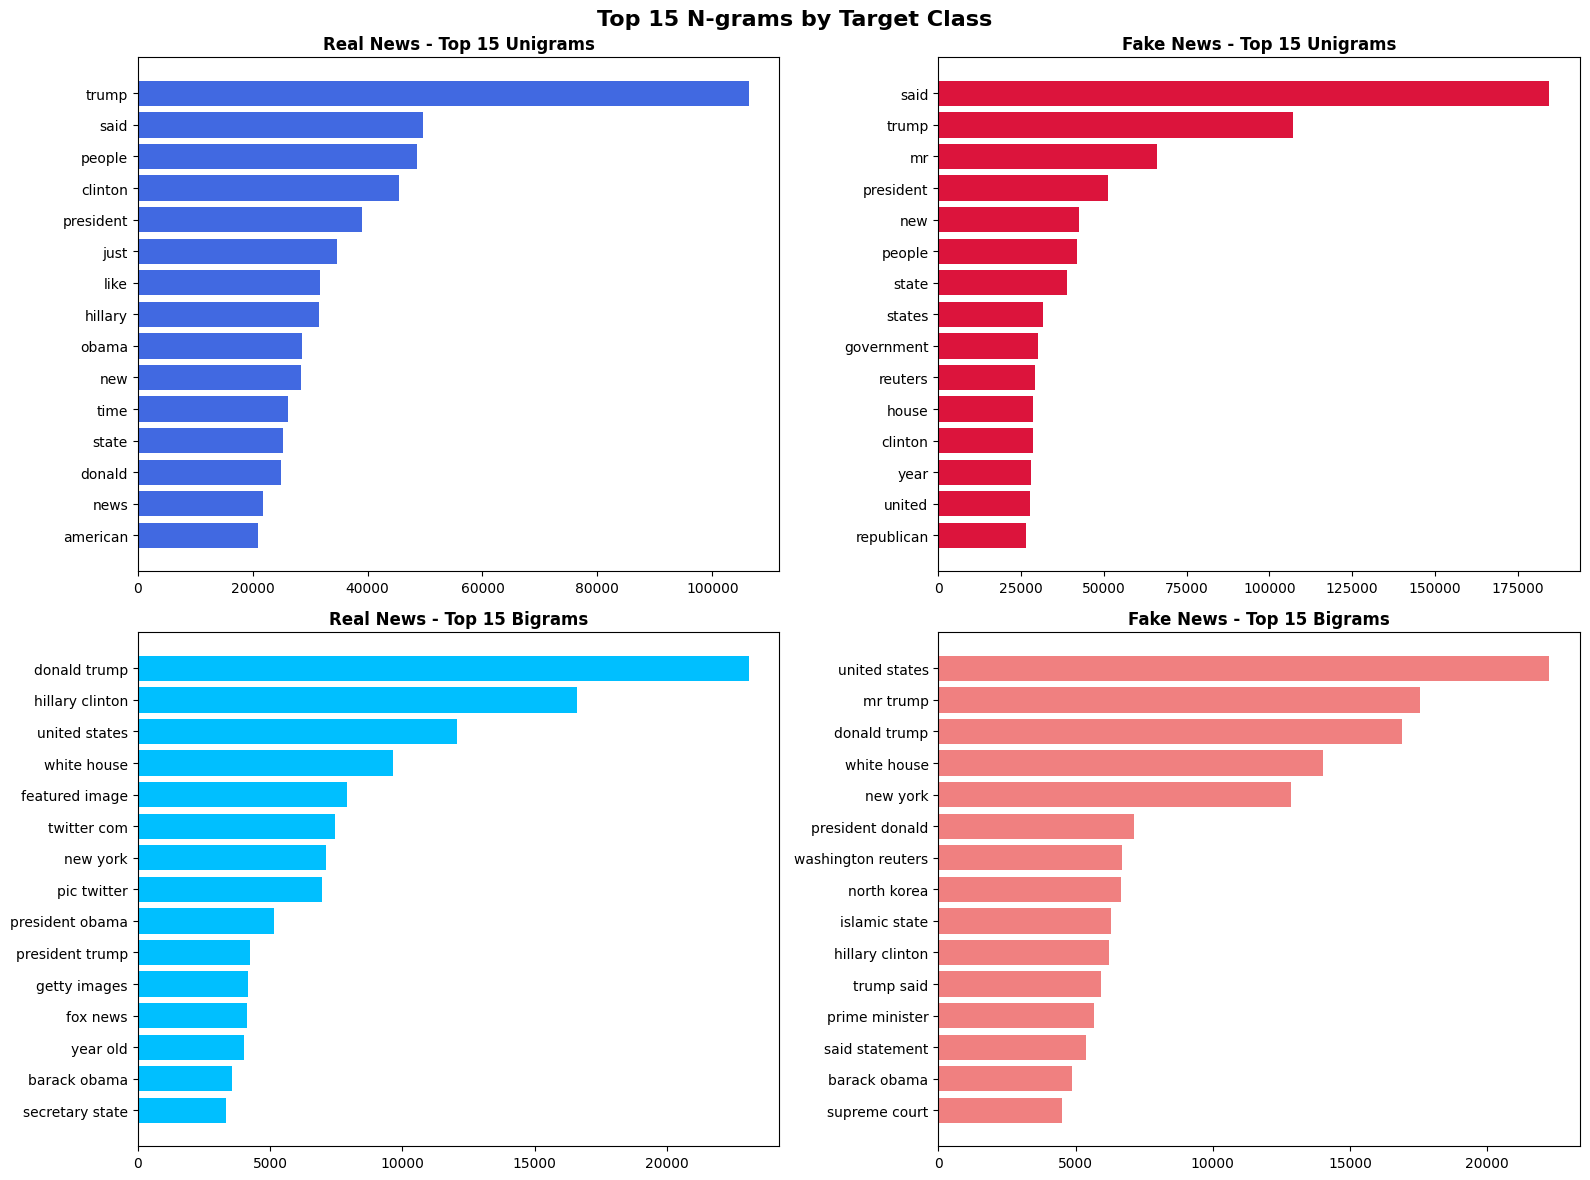

In [42]:
df = df.dropna(subset=["text"])

df_real = df[df["label"] == 1]
df_fake = df[df["label"] == 0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Top 15 N-grams by Target Class", fontsize=16, fontweight="bold")


def plot_top_ngrams(data, ngram_range, ax, title, color):
    vec = CountVectorizer(ngram_range=ngram_range, max_features=5000, stop_words="english").fit(
        data
    )
    bag_of_words = vec.transform(data)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]

    ngram_df = pd.DataFrame(words_freq, columns=["Ngram", "Count"])
    ngram_df = ngram_df.sort_values(by="Count", ascending=True)

    ax.barh(ngram_df["Ngram"], ngram_df["Count"], color=color)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.xlabel = "Count"


plot_top_ngrams(df_real["text"], (1, 1), axes[0, 0], "Real News - Top 15 Unigrams", "royalblue")
plot_top_ngrams(df_fake["text"], (1, 1), axes[0, 1], "Fake News - Top 15 Unigrams", "crimson")
plot_top_ngrams(df_real["text"], (2, 2), axes[1, 0], "Real News - Top 15 Bigrams", "deepskyblue")
plot_top_ngrams(df_fake["text"], (2, 2), axes[1, 1], "Fake News - Top 15 Bigrams", "lightcoral")

plt.tight_layout()
plt.show()

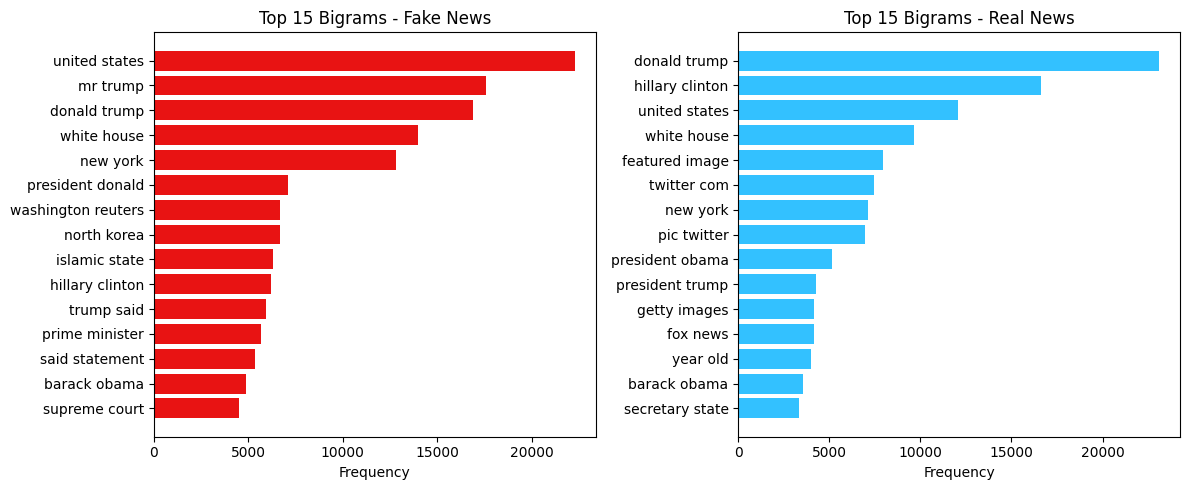

In [ ]:
fake_texts = df[df['label'] == 0]['text'].astype(str)
real_texts = df[df['label'] == 1]['text'].astype(str)


# fake bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
fake_matrix = vectorizer.fit_transform(fake_texts)

fake_counts = fake_matrix.sum(axis=0).A1
fake_vocab = vectorizer.get_feature_names_out()

fake_freq = pd.DataFrame({'bigram': fake_vocab, 'freq': fake_counts})
fake_top = fake_freq.sort_values(by='freq', ascending=False).head(15)


# real bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
real_matrix = vectorizer.fit_transform(real_texts)

real_counts = real_matrix.sum(axis=0).A1
real_vocab = vectorizer.get_feature_names_out()

real_freq = pd.DataFrame({'bigram': real_vocab, 'freq': real_counts})
real_top = real_freq.sort_values(by='freq', ascending=False).head(15)

# plot
plt.figure(figsize=(12,5))

# fake
plt.subplot(1,2,1)
plt.barh(fake_top['bigram'][::-1], fake_top['freq'][::-1], color='#E81313')
plt.title('Top 15 Bigrams - Fake News')
plt.xlabel('Frequency')

# real
plt.subplot(1,2,2)
plt.barh(real_top['bigram'][::-1], real_top['freq'][::-1], color='#33C1FF')
plt.title('Top 15 Bigrams - Real News')
plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

In [21]:
df = df[['title', 'text', 'label']]

In [22]:
# remove data with text null
df = df[["title", "text", "label"]].dropna(subset=['text'])
# substitue null values with "" in title column
df['title'] = df['title'].fillna("")

### Stylometric Feature Engineering
This section focuses on extracting stylometric features from the news articles to enhance the model's ability to distinguish between fake and real news. Stylometric features are derived from the writing style of the text and can provide insights into the authenticity of the news articles.
These features include:
- Length of the article's body (character)
- Average number of exclamation and question marks in the article's body
- Average number of uppercase words in the article's title
- Average number of exclamation and question marks in the article's title
- Count of exclamation and question marks in the article's body


In [23]:
# add column with the length of the text
df['text_length'] = df['text'].apply(len)
# add column with ratio of exclamation point and question mark in the text
df['text_exclamation_ratio'] = df['text'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with uppercase chars ratio in the title
df['title_uppercase_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
# add column with ratio of exclamation point and question mark in the title
df['title_exclamation_ratio'] = df['title'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with sum of exclamation point and question mark in the text
df['text_exclamation_count'] = df['text'].apply(lambda x: x.count('!') + x.count('?'))

C:\Users\Utente\AppData\Local\Temp\ipykernel_12880\2182510797.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='text_exclamation_ratio', palette=colors)


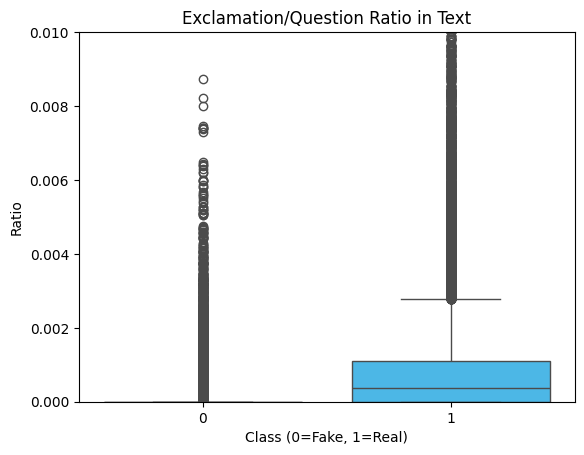

In [14]:
plt.figure()
sns.boxplot(data=df, x='label', y='text_exclamation_ratio', palette=colors)

plt.title('Exclamation/Question Ratio in Text')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')
plt.ylim(0, 0.01)  # Limit y-axis to focus on typical range

plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_12880\668407410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='text_exclamation_count', palette=colors)


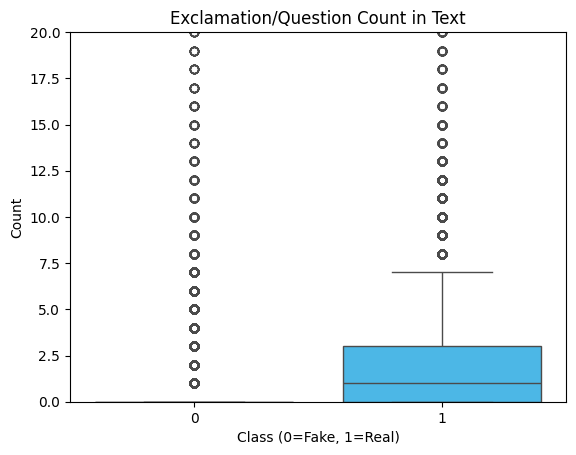

In [15]:
plt.figure()
sns.boxplot(data=df, x='label', y='text_exclamation_count', palette=colors)

plt.title('Exclamation/Question Count in Text')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Count')
plt.ylim(0, 20)  # Limit y-axis to focus on typical range

plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_12880\3980323974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='title_uppercase_ratio', palette=colors)


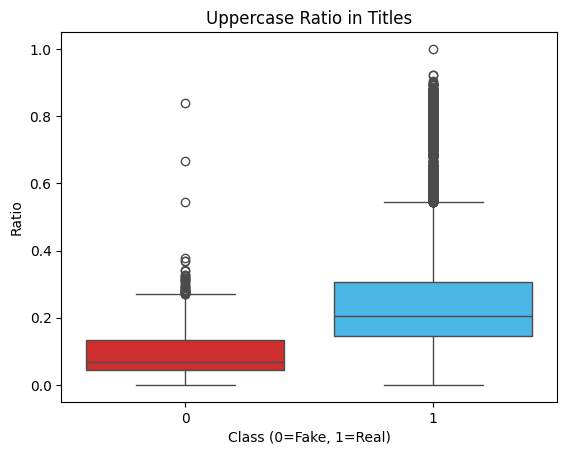

In [16]:
plt.figure()
sns.boxplot(data=df, x='label', y='title_uppercase_ratio', palette=colors)

plt.title('Uppercase Ratio in Titles')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')

plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_12880\969295750.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='title_exclamation_ratio', palette=colors)


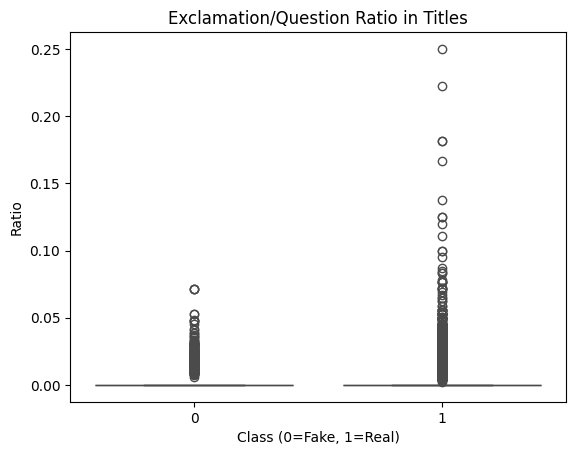

In [17]:
plt.figure()
sns.boxplot(data=df, x='label', y='title_exclamation_ratio', palette=colors)

plt.title('Exclamation/Question Ratio in Titles')
plt.xlabel('Class (0=Fake, 1=Real)')
plt.ylabel('Ratio')

plt.show()

Here we create a new feature called `full_text` by concatenating the `title` and `text` columns. This allows us to analyze the combined content of the news articles for further feature extraction and analysis.

In [24]:
df['full_text'] = df['title'] + " " + df['text']

### Linguistic Integrity and Noise Removal
First we will define a function to calculate spelling errors ratio, which is a stylometric feature that can help in distinguishing between fake and real news articles. The function will use the `pyspellchecker` library to identify misspelled words in the text and calculate the ratio of spelling errors to total words.

After that, we will apply this function to the dataset to create a new feature called `spelling_errors_ratio`. This feature will be added to our stylometric features for further analysis and modeling.


In [25]:
spell = SpellChecker()

def count_spelling_errors(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) == 0:
        return 0
    
    misspelled = spell.unknown(words)
    return len(misspelled) / len(words)


print("Calculating...")
df['spelling_errors_ratio'] = df['full_text'].apply(count_spelling_errors)
print("Done!")

Calculating...
Done!


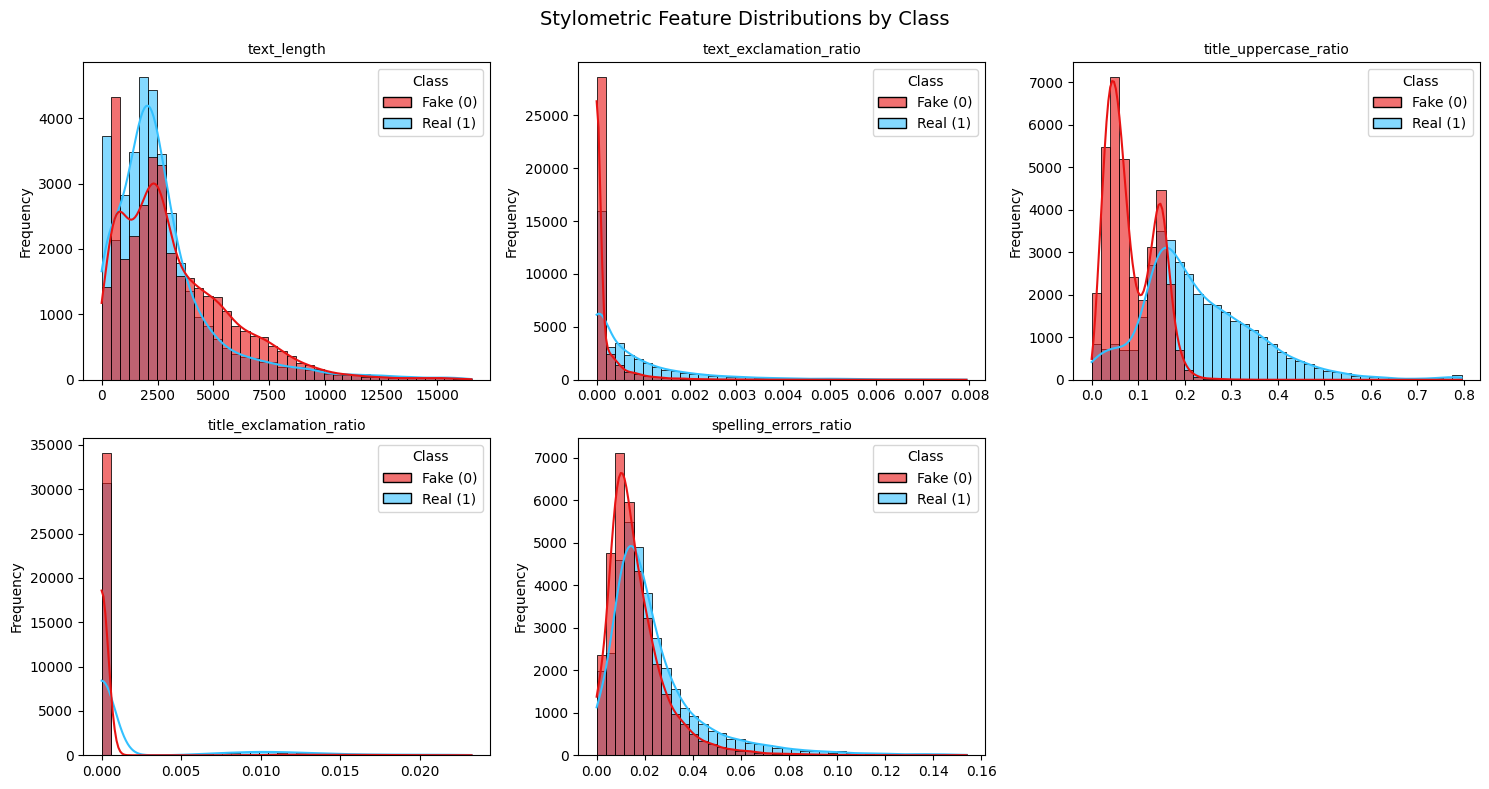

In [24]:
# ── Feature Distributions by Class ──────────────────────────────────────────
numeric_features = [
    'text_length',
    'text_exclamation_ratio',
    'title_uppercase_ratio',
    'title_exclamation_ratio',
    'spelling_errors_ratio',
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ["#E81313", '#33C1FF']

for i, feat in enumerate(numeric_features):
    q99 = df[feat].quantile(0.99)
    data_clip = df[df[feat] <= q99]

    sns.histplot(
        data=data_clip, x=feat, hue='label',
        bins=40, kde=True, kde_kws={'bw_adjust': 1.5},
        palette={0: colors[0], 1: colors[1]},
        ax=axes[i], alpha=0.6
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    legend = axes[i].get_legend()
    if legend:
        legend.set_title('Class')
        for t, lbl in zip(legend.get_texts(), ['Fake (0)', 'Real (1)']):
            t.set_text(lbl)

axes[5].set_visible(False)

plt.suptitle('Stylometric Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

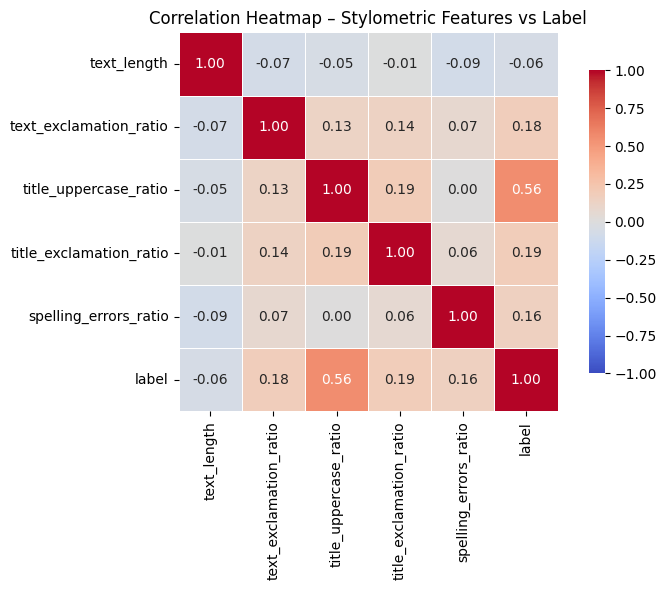

In [19]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr_cols = [
    'text_length',
    'text_exclamation_ratio',
    'title_uppercase_ratio',
    'title_exclamation_ratio',
    'spelling_errors_ratio',
    'label',
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap – Stylometric Features vs Label')
plt.tight_layout()
plt.show()

Now we will clean the text data. The processing steps include:
1. Removing tags and URLs
2. Converting text to lowercase
3. Tokenizing the text
4. Lemmatizing the tokens
5. Removing stop words and punctuation
We will define a function `clean_text` that performs these steps and apply it to the `full_text` column of our dataset to create a new column called `cleaned_text`. This cleaned text will be our X for the machine learning model.

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('wordnet')
nltk.download('omw-1.4')


stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

custom_stopwords = [
    "featured",
    "image",
    "twitter",
    "com",
    "pic",
    "getty",
    "news",
    "said",
    "mr",
    "just",
    "like",
    "year",
    "time",
    "new",
    "old",
]
stop_words.update(custom_stopwords)

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = text.lower()
    
    tokens = word_tokenize(text)

    lemmas = [lemmatizer.lemmatize(token) for token in tokens]

    cleaned_tokens = []
    for w in lemmas:
        clean_w = re.sub(r'[^\w\s]', '', w)
        if clean_w and clean_w not in stop_words:
            cleaned_tokens.append(clean_w)

    
    return " ".join(cleaned_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utente\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Utente\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Utente\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Utente\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Utente\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [22]:
df["cleaned_text"] = df["full_text"].apply(clean_text)

### Vectorization and Scaling
Here the idea is to create two separate pipelines: one for the textual features (TF-IDF) and one for the stylometric features (StandardScaler). Then we will combine them into a single feature set for modeling.

Steps:
1. Define Xs and y, one X is the textual features (the cleaned text) and the other X is the stylometric features (the engineered features).
2. Split the dataset into training and test sets (80% training, 20% test).
3. Apply TF-IDF vectorization to the textual features (fit on train, transform on test).
4. Apply MinMaxScaler to the stylometric features (fit on train, transform on test).
5. Combine the TF-IDF features and the scaled stylometric features into a single feature set for both training and test data.

This process is useful to avoid DATA LEAKAGE, ensuring that the transformations are only learned from the training data and then applied to the test data.

In [23]:
X_stylometric = df[['text_length', 'title_uppercase_ratio', 
                    'title_exclamation_ratio', 'text_exclamation_ratio', 
                    'spelling_errors_ratio']]
X_text = df['cleaned_text']
y = df['label']

X_text_train, X_text_test, X_stylo_train, X_stylo_test, y_train, y_test = train_test_split(
    X_text, X_stylometric, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

scaler = MinMaxScaler()
X_stylo_scaled_train = scaler.fit_transform(X_stylo_train)
X_stylo_scaled_test = scaler.transform(X_stylo_test)

X_train_final = hstack([X_tfidf_train, X_stylo_scaled_train])
X_test_final = hstack([X_tfidf_test, X_stylo_scaled_test])

In [24]:
# save X_train_final, X_test_final, y_train, y_test so that we can load them without having to repeat all the preprocessing steps

sparse.save_npz("saved_matrices/X_train_final.npz", X_train_final)
sparse.save_npz("saved_matrices/X_test_final.npz", X_test_final)

np.save("saved_matrices/y_train.npy", y_train)
np.save("saved_matrices/y_test.npy", y_test)


In [25]:
# save tfidf vector and stylometric scaler vector in saved_models
directory = "saved_models/"
os.makedirs(directory, exist_ok=True)

joblib.dump(tfidf, f"{directory}tfidf_vectorizer.pkl")
joblib.dump(scaler, f"{directory}stylometric_scaler.pkl")

['saved_models/stylometric_scaler.pkl']

Top 20 feature importance according to Chi-Square scores

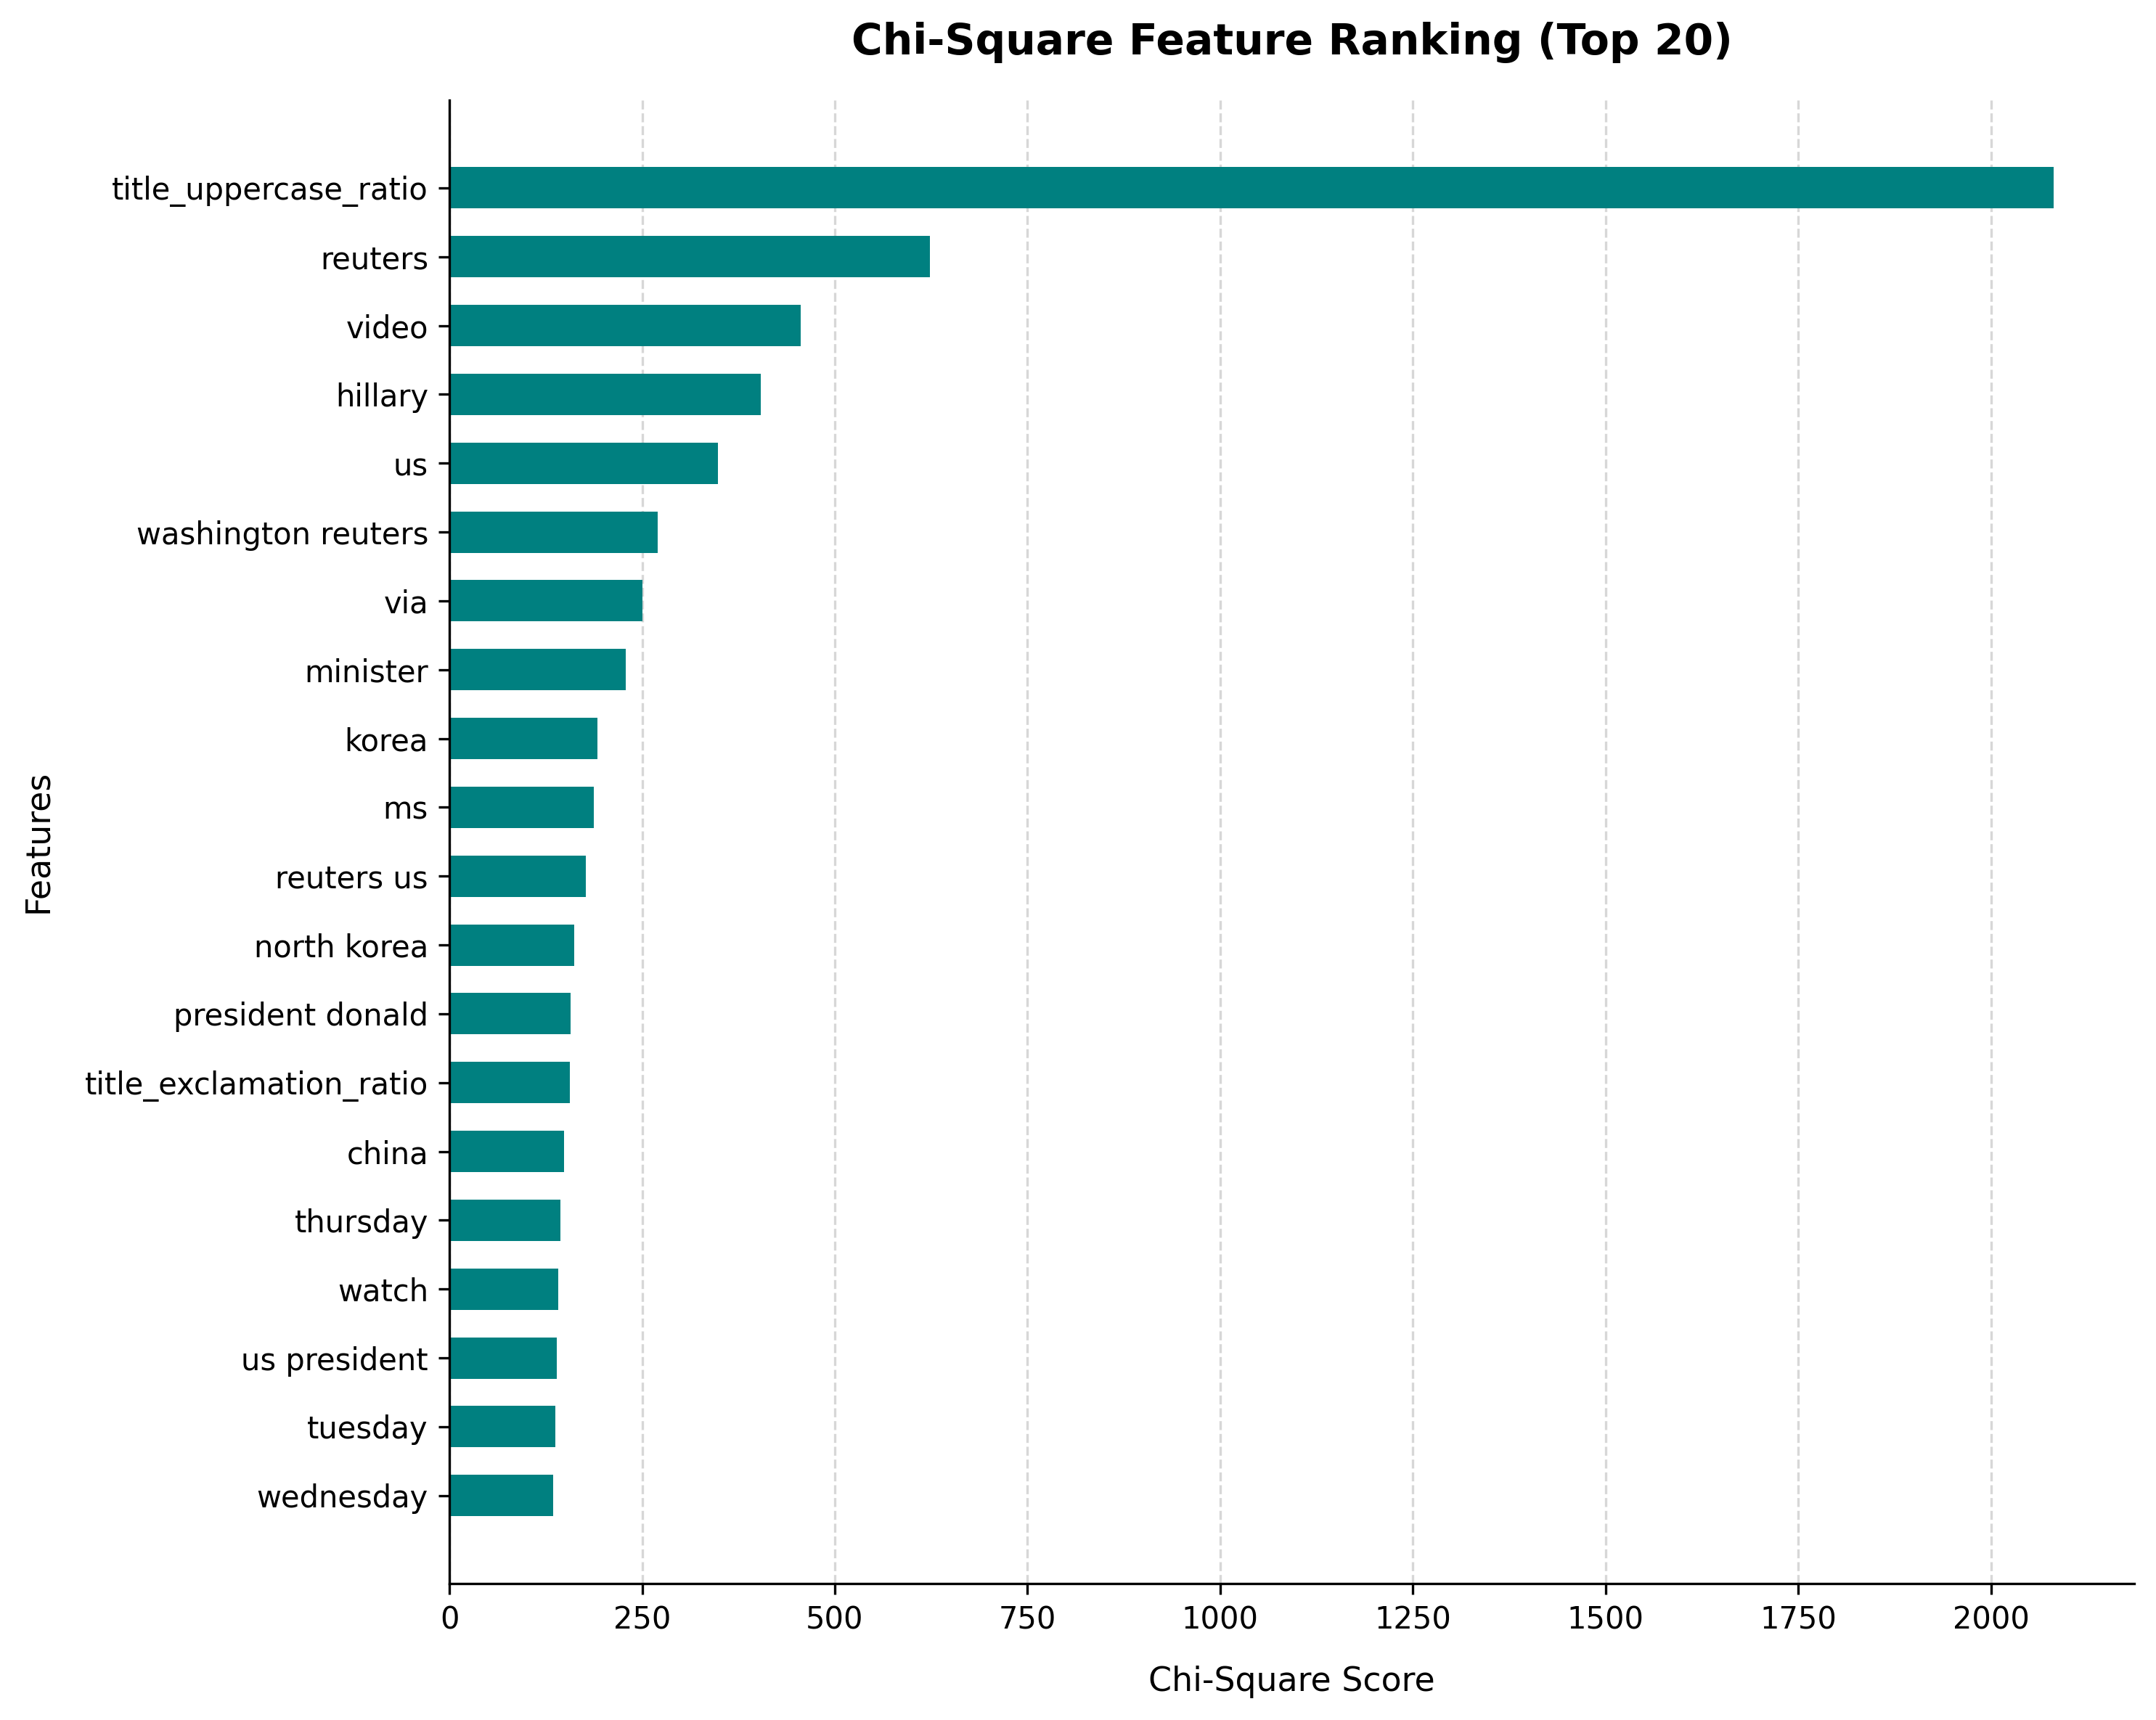

In [26]:
tfidf_features = tfidf.get_feature_names_out()
stylo_features = np.array(X_stylometric.columns)
all_feature_names = np.concatenate([tfidf_features, stylo_features])

selector = SelectKBest(score_func=chi2, k=20)
selector.fit(X_train_final, y_train)

chi2_scores = selector.scores_
mi_series = pd.Series(chi2_scores, index=all_feature_names)
mi_series = mi_series.fillna(0)
top_features = mi_series.sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8), dpi=300)
plt.title(
    "Chi-Square Feature Ranking (Top 20)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.barh(top_features.index, top_features.values, color="teal", align="center", height=0.6)
plt.xlabel("Chi-Square Score", fontsize=11, labelpad=10)
plt.ylabel("Features", fontsize=11, labelpad=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().set_axisbelow(True)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

## Model Evaluation and Hyperparameter Tuning

The script initializes a stratified cross-validation strategy. This setup maintains the target class distribution across five data folds. We define a comprehensive configuration dictionary. This structure holds six machine learning algorithms and their predefined hyperparameter search spaces. 

An execution loop processes each candidate model. The pipeline evaluates baseline models using a standard cross-validation function. The framework applies a randomized search strategy for the complex ensemble algorithms. This stochastic search explores five distinct hyperparameter combinations. The optimization process identifies the best internal configuration for each ensemble. The system fits the chosen estimator on the entire training array. The trained algorithm generates final predictions on the unseen test matrix.

In [27]:
print("=" * 60)
print("LOADING DATA MATRICES...")
print("=" * 60)
X_train_final = sparse.load_npz("saved_matrices/X_train_final.npz")
X_test_final = sparse.load_npz("saved_matrices/X_test_final.npz")
y_train = np.load("saved_matrices/y_train.npy", allow_pickle=True)
y_test = np.load("saved_matrices/y_test.npy", allow_pickle=True)
print(f"Data loaded successfully. Train shape: {X_train_final.shape}\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": None,
    },
    "Multinomial NB": {
        "model": MultinomialNB(),
        "params": None,
    },
    "Linear SVM": {
        "model": LinearSVC(dual="auto", random_state=42),
        "params": None,
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [50, 100, 150], 
            "max_depth": [10, 20, 30]
        },
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 150], 
            "learning_rate": [0.1, 1.0]
        },
    },
    "LightGBM": {
        "model": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [15, 31],
        },
    },
}

cv_results = {}
test_results = {}
best_parameters = {}

print("=" * 60)
print("STARTING MODEL TRAINING and OPTIMIZATION")
print("=" * 60)

for name, config in model_configs.items():
    print(f"\nActive Model: {name.upper()}")
    print("-" * 40)
    
    estimator = config["model"]
    param_grid = config["params"]

    if param_grid is None:
        print(f"Computing 5-Fold Cross-Validation for {name}...")
        scores = cross_val_score(
            estimator, X_train_final, y_train, cv=cv, scoring="accuracy", n_jobs=-1, verbose=3
        )
        cv_results[name] = scores

        print(f"Fitting final baseline model for {name}...")
        estimator.fit(X_train_final, y_train)
        y_pred = estimator.predict(X_test_final)
        test_results[name] = accuracy_score(y_test, y_pred)
        best_parameters[name] = "Default Parameters"

    else:
        print(f"Initializing RandomizedSearchCV (5 iterations × 5 folds = 25 total fits) for {name}...")
        random_search = RandomizedSearchCV(
            estimator,
            param_distributions=param_grid,
            n_iter=5,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1,
            random_state=42,
            verbose=3
        )
        random_search.fit(X_train_final, y_train)

        best_index = random_search.best_index_
        fold_scores = [
            random_search.cv_results_[f"split{i}_test_score"][best_index]
            for i in range(cv.n_splits)
        ]
        cv_results[name] = fold_scores

        best_model = random_search.best_estimator_
        print(f"-> Evaluating best {name} model on test data...")
        y_pred = best_model.predict(X_test_final)
        test_results[name] = accuracy_score(y_test, y_pred)
        best_parameters[name] = random_search.best_params_

    print(f"[SUCCESS] Finished processing: {name}\n")

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

summary_data = []
for name in model_configs.keys():
    summary_data.append(
        {
            "Model": name,
            "Best Params": str(best_parameters[name]),
            "Val. Accuracy": np.mean(cv_results[name]),
            "Test Accuracy": test_results[name],
        }
    )
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

LOADING DATA MATRICES...
Data loaded successfully. Train shape: (57676, 10005)

STARTING MODEL TRAINING and OPTIMIZATION

Active Model: LOGISTIC REGRESSION
----------------------------------------
Computing 5-Fold Cross-Validation for Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.0min finished


Fitting final baseline model for Logistic Regression...
[SUCCESS] Finished processing: Logistic Regression


Active Model: MULTINOMIAL NB
----------------------------------------
Computing 5-Fold Cross-Validation for Multinomial NB...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.1s finished


Fitting final baseline model for Multinomial NB...
[SUCCESS] Finished processing: Multinomial NB


Active Model: LINEAR SVM
----------------------------------------
Computing 5-Fold Cross-Validation for Linear SVM...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   21.3s finished


Fitting final baseline model for Linear SVM...
[SUCCESS] Finished processing: Linear SVM


Active Model: RANDOM FOREST
----------------------------------------
Initializing RandomizedSearchCV (5 iterations × 5 folds = 25 total fits) for Random Forest...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
-> Evaluating best Random Forest model on test data...
[SUCCESS] Finished processing: Random Forest


Active Model: ADABOOST
----------------------------------------
Initializing RandomizedSearchCV (5 iterations × 5 folds = 25 total fits) for AdaBoost...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
-> Evaluating best AdaBoost model on test data...
[SUCCESS] Finished processing: AdaBoost


Active Model: LIGHTGBM
----------------------------------------
Initializing RandomizedSearchCV (5 iterations × 5 folds = 25 total fits) for LightGBM...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
-> Evaluating best LightGBM model on test data...


c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


[SUCCESS] Finished processing: LightGBM

FINAL RESULTS SUMMARY
              Model                                                   Best Params  Val. Accuracy  Test Accuracy
Logistic Regression                                            Default Parameters       0.957920       0.959429
     Multinomial NB                                            Default Parameters       0.859266       0.856994
         Linear SVM                                            Default Parameters       0.969641       0.968375
      Random Forest                        {'n_estimators': 150, 'max_depth': 30}       0.949112       0.949997
           AdaBoost                   {'n_estimators': 150, 'learning_rate': 1.0}       0.951990       0.952008
           LightGBM {'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.1}       0.977790       0.975449


Cross-Validated Accuracy Scores Across Models

C:\Users\Utente\AppData\Local\Temp\ipykernel_12880\2940470885.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


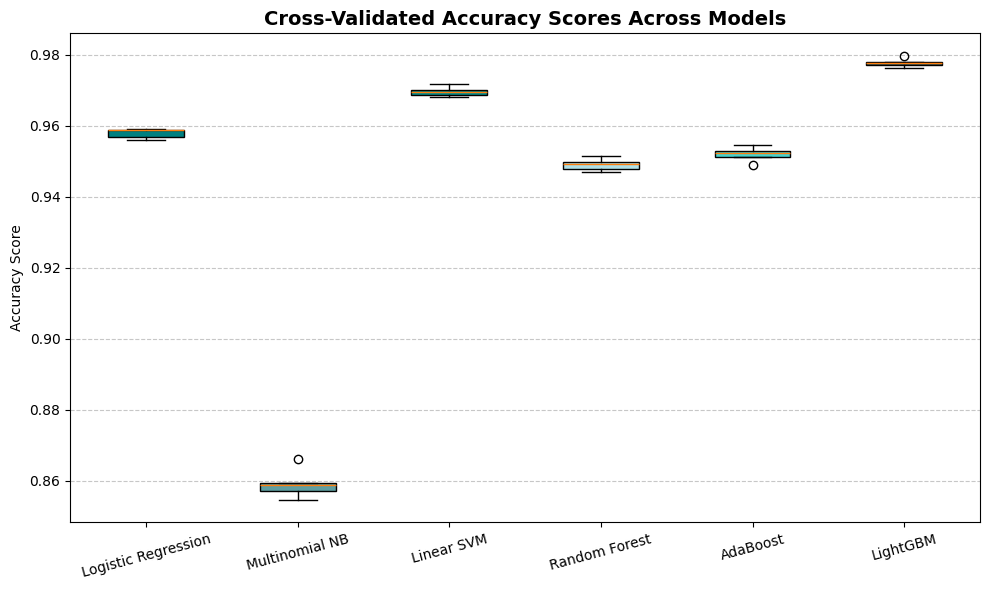

In [43]:
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    [cv_results[m] for m in model_configs.keys()],
    labels=list(model_configs.keys()),
    patch_artist=True,
)
colors = ["teal", "cadetblue", "darkcyan", "powderblue", "mediumturquoise", "darkslategray"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    
plt.title("Cross-Validated Accuracy Scores Across Models", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("cv_scores_boxplot.png", dpi=300)
plt.show()

Heatmap 2D of the high-performing model (LightGBM)

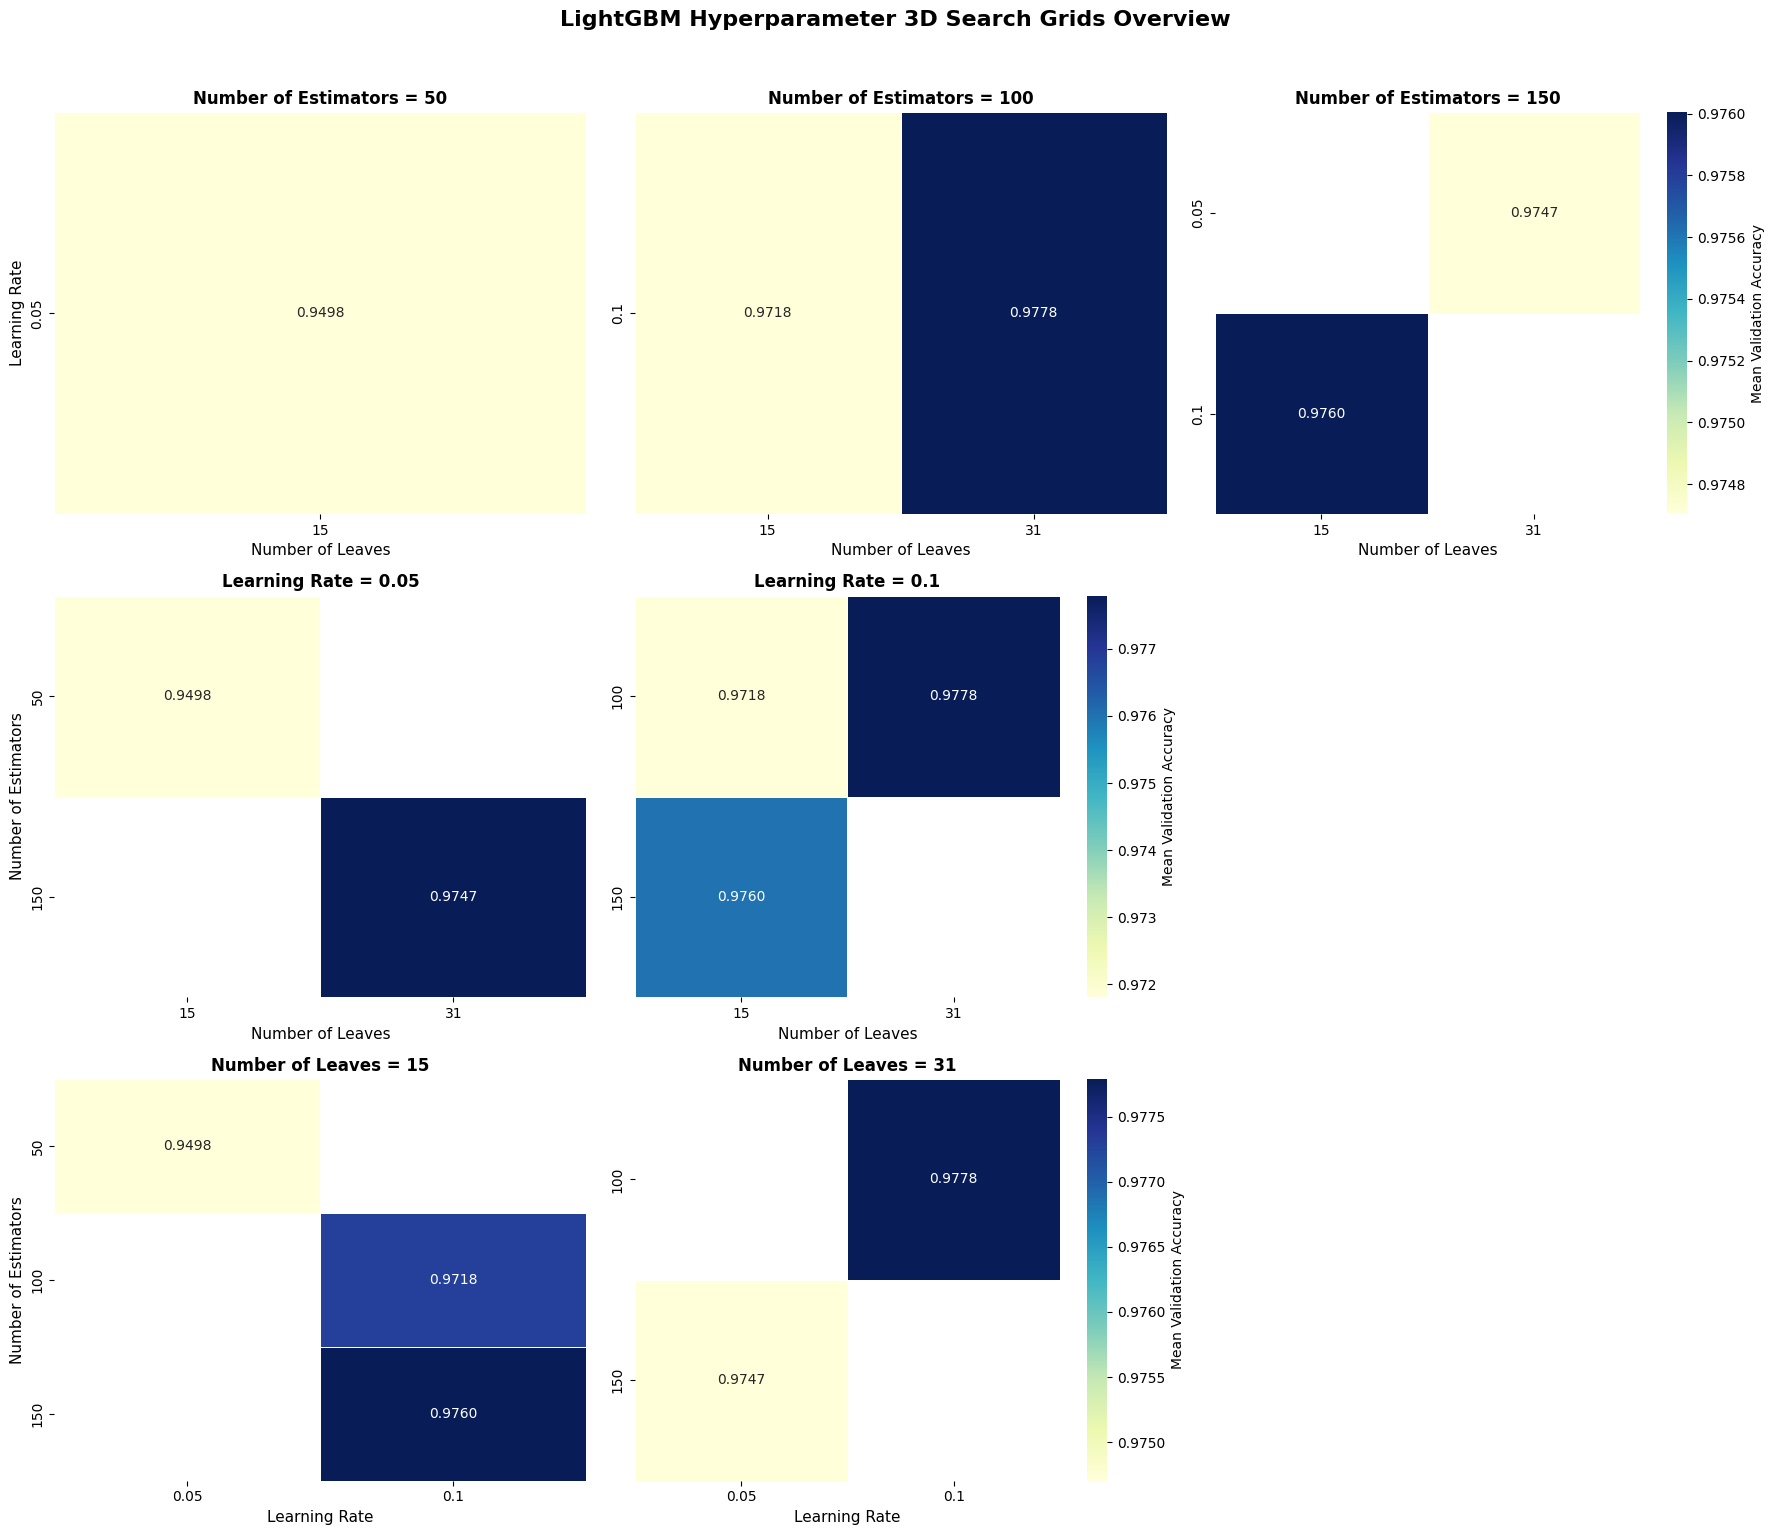

In [35]:
df_results = pd.DataFrame(random_search.cv_results_)

df_results["param_n_estimators"] = df_results["param_n_estimators"].astype(int)
df_results["param_learning_rate"] = df_results["param_learning_rate"].astype(float)
df_results["param_num_leaves"] = df_results["param_num_leaves"].astype(int)

params_config = {
    "param_n_estimators": "Number of Estimators",
    "param_learning_rate": "Learning Rate",
    "param_num_leaves": "Number of Leaves"
}

max_cols = max(len(df_results[p].dropna().unique()) for p in params_config.keys())
num_rows = len(params_config)

fig, axes = plt.subplots(num_rows, max_cols, figsize=(6 * max_cols, 5 * num_rows))

for i, (fixed_param, fixed_label) in enumerate(params_config.items()):
    other_params = [p for p in params_config.keys() if p != fixed_param]
    y_param, x_param = other_params[0], other_params[1]
    
    unique_vals = sorted(df_results[fixed_param].dropna().unique())
    
    for j in range(max_cols):
        ax = axes[i, j]
        
        if j < len(unique_vals):
            val = unique_vals[j]
            df_filtered = df_results[df_results[fixed_param] == val]
            
            try:
                heatmap_data = df_filtered.pivot(
                    index=y_param, 
                    columns=x_param, 
                    values="mean_test_score"
                )
            except ValueError:
                ax.axis('off')
                continue
            
            sns.heatmap(
                heatmap_data, 
                annot=True, 
                fmt=".4f", 
                cmap="YlGnBu", 
                linewidths=0.5,
                ax=ax,
                cbar=(j == len(unique_vals) - 1),
                cbar_kws={'label': 'Mean Validation Accuracy'} if j == len(unique_vals) - 1 else None
            )
            
            ax.set_title(f"{fixed_label} = {val}", fontsize=12, fontweight="bold")
            ax.set_xlabel(params_config[x_param], fontsize=11)
            
            if j == 0:
                ax.set_ylabel(params_config[y_param], fontsize=11)
            else:
                ax.set_ylabel("")
        else:
            ax.axis('off')

plt.suptitle("LightGBM Hyperparameter 3D Search Grids Overview", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("lightgbm_all_heatmaps_combined.png", dpi=300, bbox_inches='tight')
plt.show()

## Statistical Tests

We applied McNemar's test to compare model performances. This non-parametric test evaluates the prediction disagreement between two distinct classifiers. The method analyzes the paired nominal data from the final test set. We compared the LightGBM ensemble model against the Linear Support Vector Machine baseline.

The code generates a contingency table. This matrix captures the discordant predictions between the two architectures. The statistical evaluation calculates the Chi-squared test statistic and the associated p-value. We established a significance threshold of 0.05. The calculated p-value falls below this critical limit. We reject the null hypothesis of equal predictive accuracy. This outcome confirms the statistical superiority of the LightGBM model. The script prints a summary table to display the quantitative results.

In [32]:
svm_model = LinearSVC(dual="auto", random_state=42)
svm_model.fit(X_train_final, y_train)
y_pred_svm = svm_model.predict(X_test_final)

lgbm_params = best_parameters["LightGBM"]
lgbm_model = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, **lgbm_params)
lgbm_model.fit(X_train_final, y_train)
y_pred_lgbm = lgbm_model.predict(X_test_final)

lgbm_correct = (y_pred_lgbm == y_test)
svm_correct = (y_pred_svm == y_test)

contingency_table = np.zeros((2, 2))
contingency_table[0, 0] = np.sum(~lgbm_correct & ~svm_correct)
contingency_table[0, 1] = np.sum(~lgbm_correct & svm_correct)
contingency_table[1, 0] = np.sum(lgbm_correct & ~svm_correct)
contingency_table[1, 1] = np.sum(lgbm_correct & svm_correct)

mcnemar_result = mcnemar(contingency_table, exact=False, correction=True)

is_significant = "Yes" if mcnemar_result.pvalue < 0.05 else "No"

summary_data = [{
    "Model Comparison": "LightGBM vs. Linear SVM",
    "Test Statistic (\u03C7\u00B2)": round(mcnemar_result.statistic, 2),
    "p-value": f"{mcnemar_result.pvalue:.5f}",
    "Significant (\u03B1=0.05)": is_significant
}]

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


       Model Comparison  Test Statistic (χ²) p-value Significant (α=0.05)
LightGBM vs. Linear SVM                20.32 0.00001                  Yes


## Final Model Retraining and Evaluation

We identified the optimal hyperparameter configuration from the cross-validation stage. We instantiated the final LightGBM model using these selected parameters. We retrained this algorithm on the complete training and validation data pool, which represents the entire 80% development subset. This full retraining maximizes the data volume available to the model before deployment. It ensures that the final parameters reflect the broadest possible set of textual patterns.

We assessed model generalization using the isolated 20% test dataset. This test partition remained untouched during the feature engineering, scaling, and hyperparameter tuning phases. We passed the raw test data through the text processing pipeline fitted on the development corpus. We generated target predictions on these unseen samples. We computed accuracy, precision, recall, F1-score, and Area Under the ROC Curve (AUC-ROC) metrics to quantify the final performance. This rigorous separation guarantees an unbiased evaluation of the system in a real-world deployment scenario. We also generate the matrix confusion and the AUC-ROC curve.

c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


   Metric  Score
 Accuracy  0.975
Precision  0.971
   Recall  0.982
 F1-Score  0.976
  AUC-ROC  0.997


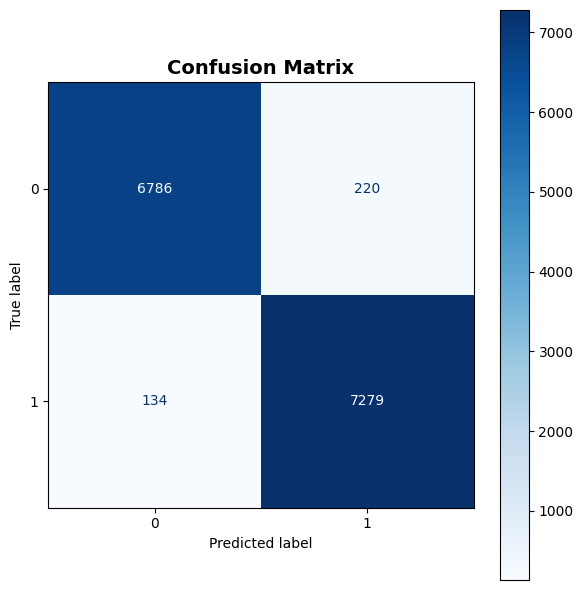

c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
c:\Users\Utente\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


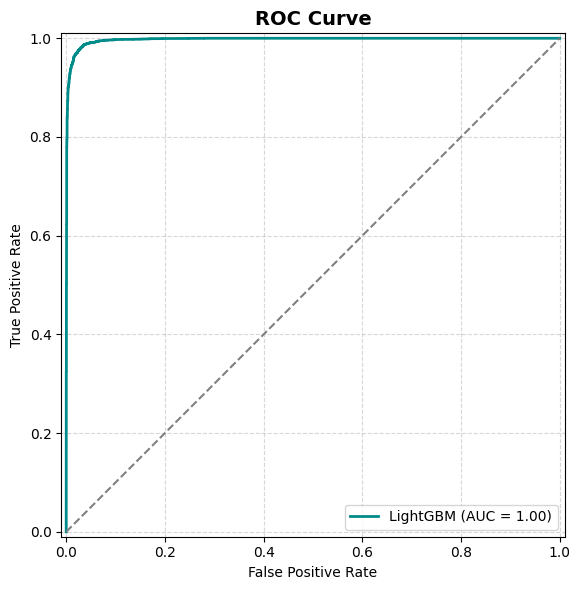

['final_lightgbm_model.pkl']

In [ ]:
lgbm_params = best_parameters["LightGBM"]
final_model = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, **lgbm_params)
final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)
y_pred_proba = final_model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],
    "Score": [round(acc, 3), round(prec, 3), round(rec, 3), round(f1, 3), round(auc, 3)],
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

cm = confusion_matrix(y_test, y_pred)
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp_cm.plot(cmap="Blues", ax=ax_cm, values_format="d")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
disp_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name="LightGBM")
disp_roc.plot(ax=ax_roc, color="darkcyan", linewidth=2)
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

directory = "saved_models/"
os.makedirs(directory, exist_ok=True)

joblib.dump(final_model, f"{directory}final_lightgbm_model.pkl")

In [43]:
# load final model and check hyperparameters
loaded_model = joblib.load(f"{directory}final_lightgbm_model.pkl")
print("Loaded LightGBM Model Hyperparameters:")
print(loaded_model.get_params())

Loaded LightGBM Model Hyperparameters:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}


## Model Explainability

We applied SHAP techniques to ensure model transparency. These explainability frameworks prevent reliance on random noise or data artifacts. We analyzed global and local feature impacts to validate the system.

The code generates a global explainability summary plot. The global feature ranking aligns with domain knowledge.

The script also provides a local explanation for a single test sample. It builds a SHAP waterfall plot. This plot visualizes the impact of individual feature values. These features shift the base expected value toward the final predicted probability.

In [5]:
final_model = joblib.load(f"./saved_models/final_lightgbm_model.pkl")

In [ ]:
print(final_model.classes_)  # sklearn wrapper



[0 1]


NameError: name 'label_encoder' is not defined

In [7]:
feature_names = list(tfidf.get_feature_names_out())

stylometric_names = [
    "title_uppercase_ratio",
    "total_word_count",
    "spelling_error_rate",
    "exclamation_mark_density",
    "question_mark_density"
]

all_feature_names = feature_names + stylometric_names

X_test_df = pd.DataFrame(X_test_final.toarray(), columns=all_feature_names)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Summary Plot (Global Explainability)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("LightGBMGlobal.png", dpi=300, bbox_inches="tight")
plt.show()

chosen_index = 2
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[chosen_index], show=False)
plt.title(f"SHAP Waterfall Plot (Local Explainability - Index {chosen_index})", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"LightGBMLocal.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'tfidf' is not defined

In [34]:
# load X and y
X_train_final = sparse.load_npz("saved_matrices/X_train_final.npz")
y_train = np.load("saved_matrices/y_train.npy", allow_pickle=True)
X_test_final = sparse.load_npz("saved_matrices/X_test_final.npz")
X_test_final = X_test_final.tocsr()
y_test = np.load("saved_matrices/y_test.npy", allow_pickle=True)
directory = "saved_models/"
final_model = joblib.load(f"{directory}final_lightgbm_model.pkl")


print("Sample Index 2 - Predicted Label:", final_model.predict(X_test_final[2]))
# print sample index 2
print("Sample Index 2 - True Label:", y_test[2]) 


Sample Index 2 - Predicted Label: [1]
Sample Index 2 - True Label: 1


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
for i in range(len(y_test)):
    pred = final_model.predict(X_test_final[i])[0]

    if pred != y_test[i]:
        print(f"First error found at index {i}")
        print(f"True label: {y_test[i]}")
        print(f"Predicted label: {pred}")
        break

c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\valida

First error found at index 61
True label: 0
Predicted label: 1


c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Advancia\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


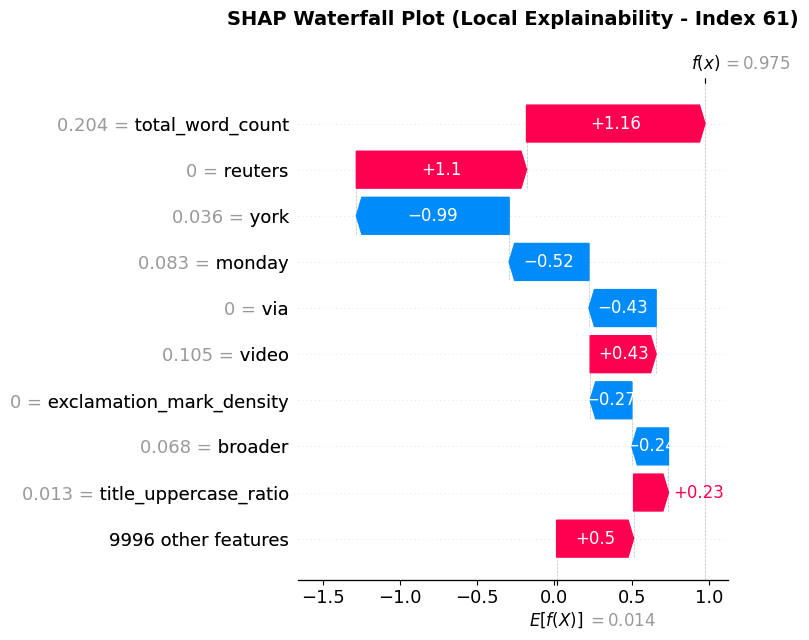

In [ ]:
tfidf = joblib.load(f"{directory}tfidf_vectorizer.pkl")
feature_names = list(tfidf.get_feature_names_out())

stylometric_names = [
    "title_uppercase_ratio",
    "total_word_count",
    "spelling_error_rate",
    "exclamation_mark_density",
    "question_mark_density"
]

all_feature_names = feature_names + stylometric_names

X_test_df = pd.DataFrame(X_test_final.toarray(), columns=all_feature_names)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_df)

chosen_index = 61
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[chosen_index], show=False)
plt.title(f"SHAP Waterfall Plot (Local Explainability - Index {chosen_index})", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"LightGBMLocalWrong.png", dpi=300, bbox_inches="tight")
plt.show()